**Taller 1 - Problema de aprendizaje supervisado**

Diego Andrés Burbano A.


## 1. Importar librerias necesarias para el modelo

In [30]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import RMSprop,Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import os
from google.colab import drive

## 2. Carga de datos

In [31]:
# En esta celda se esta montando el drive  que tiene almacenado los datos en la ruta MyDrive/datos
drive.mount('/content/drive', force_remount=True)

# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/datos/')

Mounted at /content/drive


In [32]:
data = pd.read_csv('./icml_face_data.csv', sep=',')
data.head()

,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


Revisión de datos de entrenamiento, validación y test.

In [33]:
data[' Usage'].value_counts()

,count
Usage,
Training,28709
PublicTest,3589
PrivateTest,3589


###2.1 Clasificación de emociones

Clasificación de emociones según el archivo icml_face_data.csv:

| Categoria  | Emoción  |
|:---:|:---|
| 0  | Enojo  |
| 1  | Disgusto |
| 2  |  Miedo |
| 3  |  Felicidad |
| 4  |  Tristeza |
| 5  |  Sorpresa |
| 6  | Neutral |

A continuación se presenta una distribución de la frecuencia de cada una de las clases en el conjunto de datos a utilizar para entrenar el modelo:

In [34]:
# Diccionario de mapeo
emociones_map = {
    0: "Enojo",
    1: "Disgusto",
    2: "Miedo",
    3: "Felicidad",
    4: "Tristeza",
    5: "Sorpresa",
    6: "Neutral"
}
conteo = data['emotion'].value_counts().sort_index()

tabla_conteo = pd.DataFrame({
    "Codigo": conteo.index,
    "Emocion": conteo.index.map(emociones_map),
    "Cantidad": conteo.values
})

print(tabla_conteo)

   Codigo    Emocion  Cantidad
0       0      Enojo      4953
1       1   Disgusto       547
2       2      Miedo      5121
3       3  Felicidad      8989
4       4   Tristeza      6077
5       5   Sorpresa      4002
6       6    Neutral      6198


encontramos un desbalance entre las clases que forman parte del set de datos a utilizar.

## 3. Definición de funciones

In [35]:
# Prepara la informacion - Retorna la imagen y su correspondiente etiqueta
def prepare_data(data, emotions):

    data = data[data['emotion'].isin(list(emotions.keys()))]
    image_array = np.zeros(shape=(len(data), 48, 48))
    image_label = np.array(list(map(int, data['emotion'])))

    for i, row in enumerate(data.index):
        image = np.fromstring(data.loc[row, ' pixels'], dtype=int, sep=' ')
        image = np.reshape(image, (48, 48))
        image_array[i] = image

    return image_array, image_label

##4. Selección de las emociones

In [36]:
#Selección de las emociones a clasificar (en este caso son "enojo, disgusto y sorpresa").

emotions = {0: 'Enojo', 1: 'Disgusto', 5: 'Sorpresa'}

#Selección de las emociones en la base de datos
train_image_array, train_image_label = prepare_data(data[data[' Usage']=='Training'], emotions)
val_image_array, val_image_label = prepare_data(data[data[' Usage']=='PrivateTest'], emotions)
test_image_array, test_image_label = prepare_data(data[data[' Usage']=='PublicTest'], emotions)

#Se ajusta la escala y la dimensión de las imágenes
train_images = train_image_array.reshape((train_image_array.shape[0], 48, 48, 1))
train_images = train_images.astype('float32')/255
val_images = val_image_array.reshape((val_image_array.shape[0], 48, 48, 1))
val_images = val_images.astype('float32')/255
test_images = test_image_array.reshape((test_image_array.shape[0], 48, 48, 1))
test_images = test_images.astype('float32')/255

# Crear un diccionario para mapear etiquetas personalizadas a números enteros
clase_a_numero = {clase: numero for numero, clase in enumerate(list(emotions.keys()))}

# Mapear las etiquetas del conjunto de datos a números enteros
eitquetas_entrenamiento = [clase_a_numero[etiqueta] for etiqueta in train_image_label]
eitquetas_validacion = [clase_a_numero[etiqueta] for etiqueta in val_image_label]
eitquetas_test = [clase_a_numero[etiqueta] for etiqueta in test_image_label]

train_labels = to_categorical(eitquetas_entrenamiento)
val_labels = to_categorical(eitquetas_validacion)
test_labels = to_categorical(eitquetas_test)

##5. Creación del modelo

In [37]:
# Creación del modelo
model = models.Sequential()

# Se añaden capas convolucionales
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)))

# Se añaden capa de max pooling - Reducción de dimensionalidad
model.add(MaxPool2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))

# Se añaden capa flatten, que será la entrada de la sección completamente conectada
model.add(Flatten())
model.add(Dense(64, activation='relu'))

# Dado que tenemos 3 emociones que estamos clasificando, la última capa debe tener este número de neuronas
model.add(Dense(3, activation='softmax'))

# Se compila el modelo previamente creado
model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##6. Entrenamiento del modelo

In [38]:
history = model.fit(train_images, train_labels,
                    validation_data=(val_images, val_labels),
                    epochs=5,
                    batch_size=64)

Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 27s 211ms/step - accuracy: 0.5432 - loss: 0.8595 - val_accuracy: 0.6944 - val_loss: 0.7184
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 23s 194ms/step - accuracy: 0.7139 - loss: 0.6956 - val_accuracy: 0.7443 - val_loss: 0.6333
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 41s 196ms/step - accuracy: 0.7621 - loss: 0.5894 - val_accuracy: 0.7796 - val_loss: 0.5514
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 41s 199ms/step - accuracy: 0.7959 - loss: 0.5118 - val_accuracy: 0.7890 - val_loss: 0.5233
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 41s 198ms/step - accuracy: 0.8177 - loss: 0.4696 - val_accuracy: 0.7983 - val_loss: 0.4974


##7. Predicción de las etiquetas

In [39]:
# Se predicen todas las etiquetas de los datos de test
pred_test_labels = model.predict(test_images)

# Se evalua el modelo en los datos de test y su precision
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('test accuracy:', test_acc)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8155 - loss: 0.4972
test accuracy: 0.8155650496482849


In [40]:
print('test loss: ', test_loss)

test loss:  0.48545151948928833


##8. Analisis de resultados

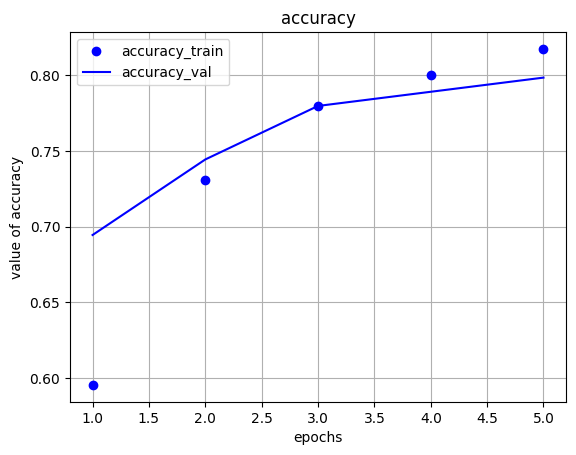

In [41]:
acc = history.history['accuracy']
acc_val = history.history['val_accuracy']
epochs = range(1, len(acc)+1)
plt.plot(epochs, acc, 'bo', label='accuracy_train')
plt.plot(epochs, acc_val, 'b', label='accuracy_val')
plt.title('accuracy')
plt.xlabel('epochs')
plt.ylabel('value of accuracy')
plt.legend()
plt.grid()
plt.show()

Complemento los resultados con una matriz de confusión y sus principales indicadores:

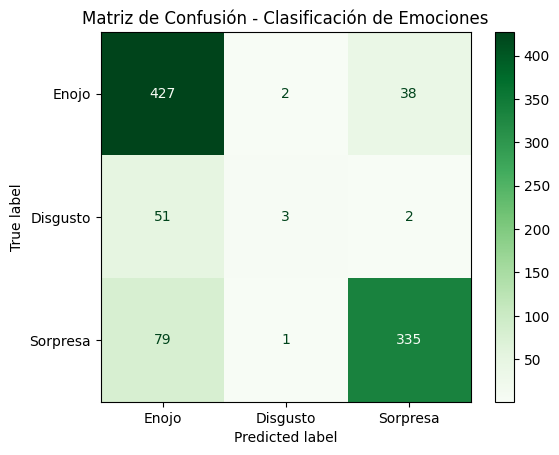

In [42]:
# Convertir las predicciones a etiquetas (número entero de clase)
y_pred = np.argmax(pred_test_labels, axis=1)
y_true = np.argmax(test_labels, axis=1)

# Nombres de las clases en el mismo orden que usaste
class_names = list(emotions.values())

# Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Mostrar matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Greens)
plt.title("Matriz de Confusión - Clasificación de Emociones")
plt.show()

In [43]:
# REPORTE DE METRICAS POR CLASE
print("Reporte de métricas por clase:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Reporte de métricas por clase:

              precision    recall  f1-score   support

       Enojo       0.77      0.91      0.83       467
    Disgusto       0.50      0.05      0.10        56
    Sorpresa       0.89      0.81      0.85       415

    accuracy                           0.82       938
   macro avg       0.72      0.59      0.59       938
weighted avg       0.81      0.82      0.80       938



Llama la atención de los resultados anteriores, específicamente los relacionados con la clase "Disgusto" ya que el modelo tiene una baja capacidad de identificar ejemplos que forma parte del set de evaluación para esta clase. Una de las razones de este resultado puede ser el desbalanceo general que presenta esta clase en el set total, contando tan solo con 547 elementos los cuales representan solo el 1.5% del total de la base de datos, siendo la clase con menor representación. Para solucionar este problema en el modelo se pueden considerar técnicas de balanceo que permitan un mejor aprendizaje.

Otra alternativa a considerar es aumentar el número de etapas o epochs del modelo a fin de permitir que el mismo aprenda mas del set de entrenamiento con el propósito de asegurar una mayor capacidad de generalización.


In [44]:
# RE-ENTRENAMIENTO DEL MODELO (epoch = 10)
#Entrenamiento del modelo modificando el hiper parámetro epoch para considerar 10 etapas:
history = model.fit(train_images, train_labels,
                    validation_data=(val_images, val_labels),
                    epochs=10,
                    batch_size=64)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 203ms/step - accuracy: 0.8180 - loss: 0.4467 - val_accuracy: 0.8129 - val_loss: 0.4786
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 187ms/step - accuracy: 0.8502 - loss: 0.3937 - val_accuracy: 0.8087 - val_loss: 0.4644
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - accuracy: 0.8511 - loss: 0.3832 - val_accuracy: 0.8233 - val_loss: 0.4363
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 44s 219ms/step - accuracy: 0.8695 - loss: 0.3426 - val_accuracy: 0.8243 - val_loss: 0.4551
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 186ms/step - accuracy: 0.8779 - loss: 0.3185 - val_accuracy: 0.8264 - val_loss: 0.4483
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 208ms/step - accuracy: 0.8921 - loss: 0.2781 - val_accuracy: 0.8368 - val_loss: 0.4387
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 23s 197ms/step - accuracy: 0.9056 - loss: 0.2434 - val_accuracy: 0.8295 - val_loss: 0.4451
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 41s 201ms/step - accuracy: 0.9239 - loss: 0

In [45]:
# PREDICCION DE LAS ETIQUETAS
# Se predicen todas las etiquetas de los datos de test
pred_test_labels = model.predict(test_images)

# Se evalua el modelo en los datos de test y su precision
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('test accuracy:', test_acc)
print('test loss: ', test_loss)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8533 - loss: 0.5645
test accuracy: 0.8507462739944458
test loss:  0.5627825856208801


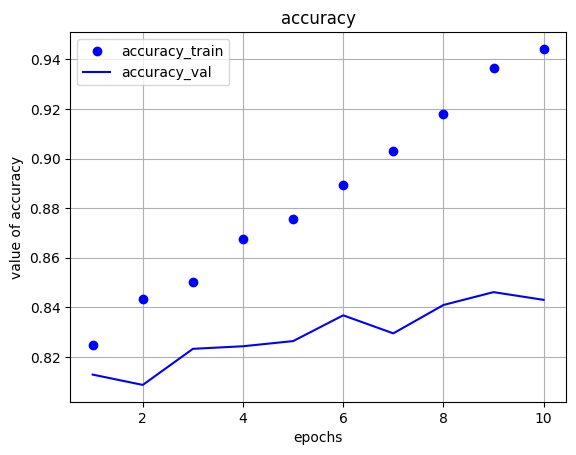

In [46]:
#GRAFICA DEL ACCURACY DEL MODELO:
acc = history.history['accuracy']
acc_val = history.history['val_accuracy']
epochs = range(1, len(acc)+1)
plt.plot(epochs, acc, 'bo', label='accuracy_train')
plt.plot(epochs, acc_val, 'b', label='accuracy_val')
plt.title('accuracy')
plt.xlabel('epochs')
plt.ylabel('value of accuracy')
plt.legend()
plt.grid()
plt.show()


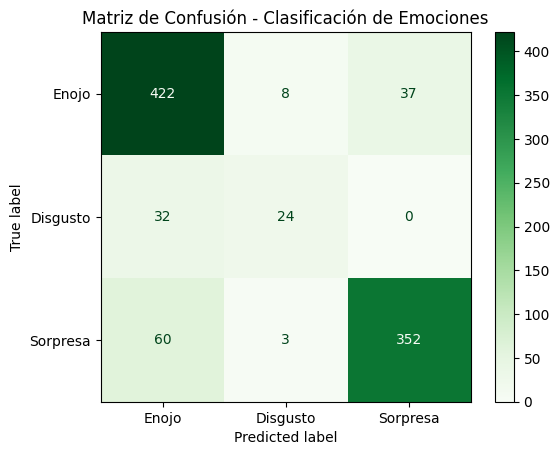

In [47]:
#MATRIZ DE CONFUSION
# Convertir las predicciones a etiquetas (número entero de clase)
y_pred = np.argmax(pred_test_labels, axis=1)
y_true = np.argmax(test_labels, axis=1)

# Nombres de las clases en el mismo orden que usaste
class_names = list(emotions.values())

# Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Mostrar matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Greens)
plt.title("Matriz de Confusión - Clasificación de Emociones")
plt.show()

In [48]:
# Reporte de métricas por clase
print("Reporte de métricas por clase:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Reporte de métricas por clase:

              precision    recall  f1-score   support

       Enojo       0.82      0.90      0.86       467
    Disgusto       0.69      0.43      0.53        56
    Sorpresa       0.90      0.85      0.88       415

    accuracy                           0.85       938
   macro avg       0.80      0.73      0.75       938
weighted avg       0.85      0.85      0.85       938



Como resultado del re-entrenamiento del modelo los indicadores de precisión, recall y f1 presentan una considerable mejora para los elementos de la clase "Disgusto".

Para las clases "Enojo" y "Sorpresa" el nuevo modelo arroja una mejora en cada uno de los indicadores.

Se puede concluir por lo tanto que el modelo re-entrenado tiene una mayor capacidad de generalización frente al modelo original.


##9. Conclusiones

1. El problema de reconocimiento de sentimientos a partir de imágenes sigue siendo un caso adecuado para aplicar técnicas de Machine Learning, aunque el análisis revela aspectos importantes a considerar:

a. Disponibilidad de datos y retos de balanceo: Se cuenta con un dataset amplio
y con anotaciones confiables, lo que permite entrenar modelos con capacidad de generalización. Sin embargo, existe un desbalance entre clases que influye en el rendimiento, por lo que podrían explorarse técnicas de balanceo (oversampling, undersampling o generación sintética de datos) para mejorar la equidad del aprendizaje.

b. Baja criticidad operativa: La tarea no está asociada a decisiones que afecten la seguridad, la salud o derechos fundamentales de las personas, lo que la hace viable para automatización.

c. Escalabilidad y aprendizaje progresivo: Los resultados muestran que el rendimiento del modelo mejora al incrementar las épocas de entrenamiento, lo que evidencia potencial para perfeccionarse con más datos, ajustes de hiperparámetros y estrategias de regularización.

d. Consideraciones éticas y de privacidad: El tratamiento de las imágenes no implica el manejo de información sensible ni pone en riesgo la privacidad de grupos o individuos, realizándose bajo un marco de uso legítimo de datos.

2. En relación a los elementos que forman parte del modelo, nos referiremos primeramente al conjunto de datos: Si bien como ya mencionamos se trata de un dataset amplio, existe un desbalance entre clases. De ahí surge la necesidad de prepararlo o ajustarlo adecuadamente por medio de técnicas de balanceo.

3. Si bien el desarrollo del problema se ha trabajado con redes neuronales, no es el único modelo a considerar. Se puede optar por utilizar modelos tales como Regresión Logística, el cual con regularización puede manejar el desbalance ya anotado, o Arboles de Decisión, Modelos basados en distancias (KNN) entre otros. Y como lo vimos en los diferentes ejemplos del curso, realizar un analisis comparativo una vez ejecutados y de esta manera determinar cual de ellos generaliza de la mejor manera.

4. Finalmente nos centraremos en otro elemento del problema de aprendizaje supervisado como es el entrenamiento del modelo. En el ejemplo inicial se planteó utilizar como uno de los hiper-parámetros de entrenamiento el número de epochs igual a 5. Ejecutando el modelo y analizando los resultados en la matriz de confusión, podemos observar que el recall para la clase "Disgusto" es muy bajo (0,05 = 3 / 56) debido al desbalance del set de datos. Por este motivo tomamos la decisión de re-entrenar el modelo incrementando a 10 el número de epochs, logrando de esta manera un importante incremento en este indicador (0.43 = 24 / 56). Si bien en la práctica se pueden utilizar técnicas como GridSearch o Random Search para encontrar el mejor parámetro, controlando el riesgo de sobreajuste, hicimos un incremento en el hiperparámetro de manera empírica, logrando que el modelo re-entrenado generalice mejor que el modelo original, no solo para la clase "Disgusto" sino que la mejora se presenta en todas las clases evaluadas.
De esta manera se concluye que el entrenamiento del modelo es uno de los elementos mas importantes en el momento de ejecutar modelos de Machine Learning.  
